# Лекция 2. Разбор упражнений

Упражнения из раздела 12 конспекта [`lecture02.md`](lecture02.md). Каждое разбирается по одной схеме:

1. **условие**;
2. **решение по шагам** — доказательство по определению, критерию или через операции; для невыпуклых — контрпример;
3. **проверка кодом** — тот же вывод получаем численно, и картинка.

Сначала попробуйте решить сами. Краткие ответы без кода — в [`exercises02.md`](exercises02.md); как проверять выпуклость кодом — в [`demo02.ipynb`](demo02.ipynb).

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle
from scipy.optimize import linprog, minimize

BLUE, ORANGE, AQUA, YELLOW, RED, VIOLET = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e34948", "#4a3aa7"
GRAY, INK = "#8a8985", "#0b0b0b"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.2, "legend.frameon": False})
rng = np.random.default_rng(2)


def segment(ax, a, b, inside, n=300):
    """Рисует отрезок [a, b]: зелёным там, где он внутри множества, красным пунктиром — где вышел."""
    a, b = np.asarray(a, float), np.asarray(b, float)
    pts = a + np.linspace(0, 1, n)[:, None] * (b - a)
    ok = np.array([inside(p) for p in pts])
    for i in range(n - 1):
        col, ls = (AQUA, "-") if ok[i] and ok[i + 1] else (RED, "--")
        ax.plot(pts[i:i + 2, 0], pts[i:i + 2, 1], color=col, ls=ls, lw=2.2)
    ax.plot(*a, "o", color=INK, ms=5); ax.plot(*b, "o", color=INK, ms=5)
    return ok.all()


def chord_violation(f, sample, n=5000):
    """Максимальное нарушение неравенства хорды на n случайных парах; 0 — нарушений не найдено."""
    worst = 0.0
    for _ in range(n):
        x, y, t = sample(), sample(), rng.uniform()
        worst = max(worst, f((1 - t) * x + t * y) - ((1 - t) * f(x) + t * f(y)))
    return worst

## 12.1. Выпуклы ли множества?

> Докажите или предъявите две точки и вылезающий отрезок:
> (а) $\{x : \Vert x - a\Vert_2 \le r\}$; (б) $\{x : x^\top Q x \le 1\}$ при $Q \succ 0$, и при $Q$ с отрицательным собственным числом; (в) $\{x \in \mathbb{R}^2 : x_1 x_2 \ge 1,\ x_1 > 0,\ x_2 > 0\}$; (г) $\{x_1^2 + x_2^2 = 1\}$; (д) $\{\Vert x\Vert \le 1\} \cup \{\Vert x - (3, 0)\Vert \le 1\}$.

Способ доказать выпуклость — один из трёх: подставить выпуклую комбинацию в определение; представить множество как пересечение / аффинный образ выпуклых; представить как подуровневое множество выпуклой функции. Способ опровергнуть — один: две точки и отрезок.

**(а) Шар — выпукл.** Пусть $\Vert x - a\Vert \le r$, $\Vert y - a\Vert \le r$. Тогда для $z = (1-t)x + ty$

$$\Vert z - a\Vert = \Vert (1-t)(x - a) + t(y - a)\Vert \le (1-t)\Vert x - a\Vert + t\Vert y - a\Vert \le r$$

по неравенству треугольника и однородности нормы. Тот же аргумент работает для любой нормы.

**(б) Эллипсоид.** При $Q \succ 0$ функция $x^\top Q x$ выпукла (гессиан $2Q \succ 0$), а множество — её подуровневое множество $\{f \le 1\}$, значит, выпукло. Если у $Q$ есть отрицательное собственное число, $x^\top Qx \le 1$ задаёт область между ветвями гиперболы, и она не выпукла: для $Q = \operatorname{diag}(1, -1)$ точки $(2, 1.9)$ и $(2, -1.9)$ лежат в множестве ($4 - 3.61 \le 1$), а их середина $(2, 0)$ — нет ($4 > 1$).

**(в) $x_1 x_2 \ge 1$ в положительном квадранте — выпукло.** При $x_1 > 0$ условие равносильно $x_2 \ge 1/x_1$, то есть множество — надграфик функции $1/x_1$, выпуклой на $x_1 > 0$ ($f'' = 2/x_1^3 > 0$). Другой способ: множество — подуровневое $\{-\log x_1 - \log x_2 \le 0\}$ выпуклой функции. Заметьте: сама функция $x_1 x_2$ не выпукла (гессиан $\begin{pmatrix} 0 & 1 \\ 1 & 0\end{pmatrix}$ индефинитен), но её *над*уровневое множество в квадранте выпукло — так бывает.

**(г) Окружность — не выпукла.** Точки $(1, 0)$ и $(-1, 0)$ лежат на окружности, их середина $(0, 0)$ — нет.

**(д) Объединение шаров — не выпукло.** Точки $(0, 0)$ и $(3, 0)$ принадлежат объединению, середина $(1.5, 0)$ находится на расстоянии $1.5 > 1$ от обоих центров.

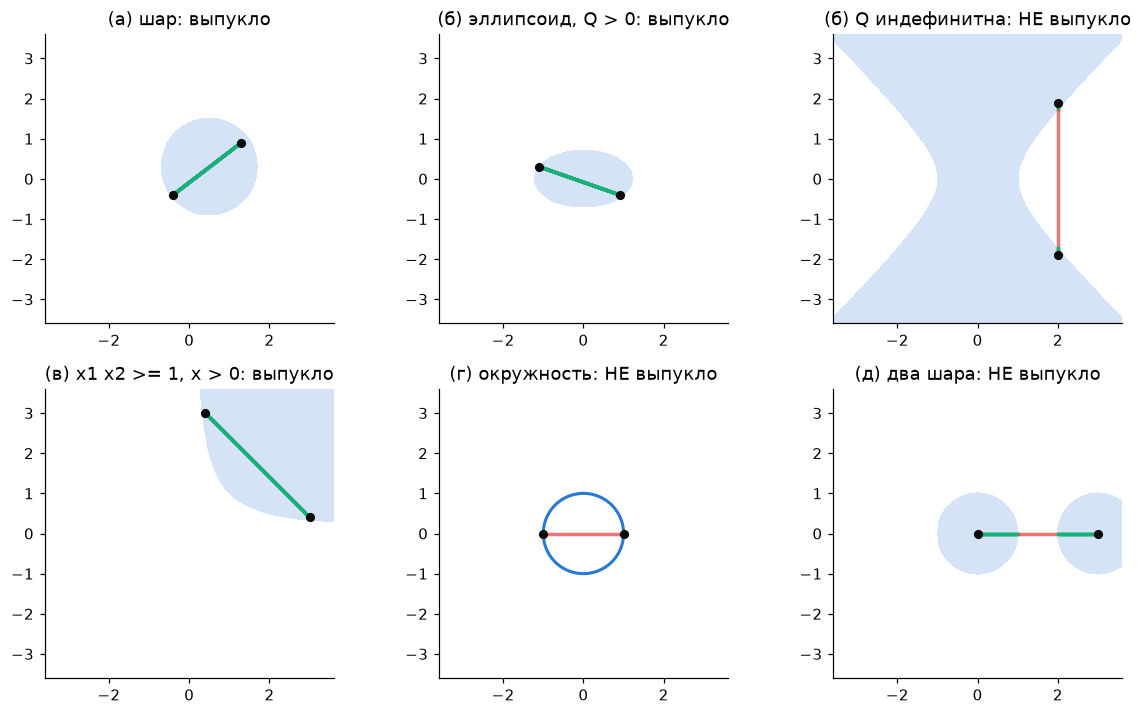

In [2]:
Qh = np.diag([1.0, -1.0])
sets = [
    ("(а) шар",                 lambda p: np.linalg.norm(p - [0.5, 0.3]) <= 1.2,          [(-0.4, -0.4), (1.3, 0.9)]),
    ("(б) эллипсоид, Q > 0",    lambda p: p @ np.diag([1.0, 3.0]) @ p <= 1.5,             [(-1.1, 0.3), (0.9, -0.4)]),
    ("(б) Q индефинитна",       lambda p: p @ Qh @ p <= 1,                                [(2.0, 1.9), (2.0, -1.9)]),
    ("(в) x1 x2 >= 1, x > 0",   lambda p: p[0] > 0 and p[1] > 0 and p[0] * p[1] >= 1,     [(0.4, 3.0), (3.0, 0.4)]),
    ("(г) окружность",          lambda p: abs(p @ p - 1) < 0.01,                          [(1.0, 0.0), (-1.0, 0.0)]),
    ("(д) два шара",            lambda p: min(np.linalg.norm(p), np.linalg.norm(p - [3, 0])) <= 1, [(0.0, 0.0), (3.0, 0.0)]),
]
fig, axes = plt.subplots(2, 3, figsize=(11, 6.6))
t = np.linspace(0, 2 * np.pi, 200)
for ax, (name, inside, (a, b)) in zip(axes.flat, sets):
    lim = 3.6
    xs = np.linspace(-lim, lim, 300); X1, X2 = np.meshgrid(xs, xs)
    M = np.array([[inside(np.array([u, v])) for u in xs] for v in xs])
    ax.contourf(X1, X2, M.astype(float), levels=[0.5, 1.5], colors=[BLUE], alpha=0.2)
    if "окружность" in name:
        ax.plot(np.cos(t), np.sin(t), color=BLUE, lw=2)
    ok = segment(ax, a, b, inside)
    ax.set(title=f"{name}: {'выпукло' if ok else 'НЕ выпукло'}", xlim=(-lim, lim), ylim=(-lim, lim), aspect="equal")
    ax.grid(False)
plt.tight_layout(); plt.show()

Зелёный отрезок целиком внутри — тест пройден (для доказательства этого мало, но картинка совпадает с выкладкой), красный пунктир — отрезок вышел, и это уже строгое опровержение.

## 12.2. Выпуклы ли функции?

> (а) $x_1^2 / x_2$ на $x_2 > 0$; (б) $-\log x$ и $x\log x$ на $x > 0$; (в) $x^4 - x^2$; (г) $\log(e^{x_1} + e^{x_2})$.

Для гладких функций — критерий второго порядка: $\nabla^2 f \succeq 0$ всюду на области.

**(а) $f = x_1^2 / x_2$ — выпукла на $x_2 > 0$.** Градиент $\nabla f = (2x_1/x_2,\ -x_1^2/x_2^2)$, гессиан

$$\nabla^2 f = \frac{2}{x_2^3}\begin{pmatrix} x_2^2 & -x_1 x_2 \\ -x_1 x_2 & x_1^2 \end{pmatrix}, \qquad v^\top \nabla^2 f\, v = \frac{2}{x_2^3}\,(x_2 v_1 - x_1 v_2)^2 \ge 0 .$$

Гессиан вырожден (собственное число $0$ вдоль направления $v \parallel x$: функция однородна степени 1 и на лучах из нуля линейна), но полуопределён — выпукла, не строго.

**(б)** $(-\log x)'' = 1/x^2 > 0$ и $(x\log x)'' = 1/x > 0$ при $x > 0$: обе строго выпуклы.

**(в) $x^4 - x^2$ — не выпукла.** $f'' = 12x^2 - 2 < 0$ при $|x| < 1/\sqrt6$. Контрпример хордой: $f(\pm 0.5) = -3/16$, а в середине $f(0) = 0 > -3/16$.

**(г) $\log(e^{x_1} + e^{x_2})$ — выпукла.** Обозначим $p_i = e^{x_i} / (e^{x_1} + e^{x_2})$, тогда $\nabla f = p$ и $\nabla^2 f = \operatorname{diag}(p) - p p^\top$. Для любого $v$

$$v^\top \nabla^2 f\, v = \sum_i p_i v_i^2 - \Big(\sum_i p_i v_i\Big)^2 \ge 0$$

— это дисперсия величины $v_i$ с весами $p_i$ (или неравенство Коши–Буняковского). Функция «log-sum-exp» — гладкая выпуклая аппроксимация $\max(x_1, x_2)$ и основа логистической регрессии.

(а) x1^2/x2, x2>0      min λ_min гессиана по 500 точкам = -3.63e-08;  нарушение хорды = 0.0e+00
(г) log(e^x1+e^x2)     min λ_min гессиана по 500 точкам = -3.33e-08;  нарушение хорды = 0.0e+00
отрицательные значения порядка 1e-8 — погрешность конечных разностей: гессиан полуопределён


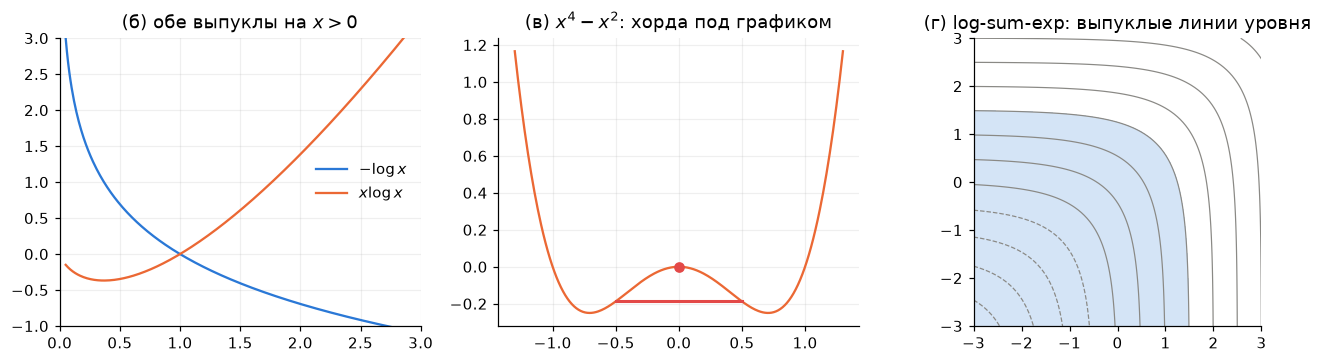

In [3]:
def hess_fd(f, x, eps=1e-4):
    x = np.asarray(x, float); n = x.size; H = np.zeros((n, n)); E = np.eye(n) * eps
    for i in range(n):
        for j in range(n):
            H[i, j] = (f(x + E[i] + E[j]) - f(x + E[i] - E[j]) - f(x - E[i] + E[j]) + f(x - E[i] - E[j])) / (4 * eps**2)
    return 0.5 * (H + H.T)

funcs = {
    "(а) x1^2/x2, x2>0": (lambda x: x[0] ** 2 / x[1],                 lambda: np.array([rng.uniform(-3, 3), rng.uniform(0.3, 3)])),
    "(г) log(e^x1+e^x2)": (lambda x: np.logaddexp(x[0], x[1]),         lambda: rng.uniform(-3, 3, 2)),
}
for name, (f, sample) in funcs.items():
    lam = np.array([np.linalg.eigvalsh(hess_fd(f, sample()))[0] for _ in range(500)])
    print(f"{name:22s} min λ_min гессиана по 500 точкам = {lam.min(): .2e};  нарушение хорды = {chord_violation(f, sample):.1e}")

print("отрицательные значения порядка 1e-8 — погрешность конечных разностей: гессиан полуопределён")

f_c = lambda x: x**4 - x**2
x = np.linspace(-1.3, 1.3, 300)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
xp = np.linspace(0.05, 3, 300)
axes[0].plot(xp, -np.log(xp), color=BLUE, label="$-\\log x$"); axes[0].plot(xp, xp * np.log(xp), color=ORANGE, label="$x\\log x$")
axes[0].set(title="(б) обе выпуклы на $x > 0$", xlim=(0, 3), ylim=(-1, 3)); axes[0].legend()
axes[1].plot(x, f_c(x), color=ORANGE); axes[1].plot([-0.5, 0.5], [f_c(-0.5), f_c(0.5)], color=RED, lw=2)
axes[1].plot(0, 0, "o", color=RED); axes[1].set(title="(в) $x^4 - x^2$: хорда под графиком")
xs = np.linspace(-3, 3, 100); X1, X2 = np.meshgrid(xs, xs)
axes[2].contour(X1, X2, np.logaddexp(X1, X2), levels=12, colors=[GRAY], linewidths=0.8)
axes[2].contourf(X1, X2, np.logaddexp(X1, X2), levels=[-10, 1.5], colors=[BLUE], alpha=0.2)
axes[2].set(title="(г) log-sum-exp: выпуклые линии уровня", aspect="equal"); axes[2].grid(False)
plt.tight_layout(); plt.show()

## 12.3. Выпуклость через операции

> Докажите выпуклость (а) $\Vert Ax - b\Vert_2^2 + \lambda\Vert x\Vert_1$, $\lambda \ge 0$; (б) $\max_i \lvert a_i^\top x - b_i\rvert$; (в) $\sum_i \log(1 + e^{-y_i a_i^\top x})$. Какие из них гладкие?

Здесь гессиан не нужен (а для негладких функций его и нет): собираем из кирпичей по правилам раздела 5 конспекта.

**(а) LASSO.** $\Vert Ax - b\Vert_2^2 = x^\top (A^\top A) x - 2b^\top A x + b^\top b$ — квадратичная с $2A^\top A \succeq 0$, выпукла. $\Vert x\Vert_1$ — норма, выпукла. Неотрицательная сумма выпуклых выпукла. **Негладкая**: $\Vert x\Vert_1 = \sum |x_i|$ не дифференцируема там, где какая-то координата равна нулю — именно в таких точках LASSO и любит находить решения (разреженность).

**(б) Чебышёвская подгонка.** $\lvert u\rvert = \max(u, -u)$ — максимум двух аффинных функций от $u$; при $u = a_i^\top x - b_i$ (аффинная замена) получаем выпуклую функцию от $x$; максимум по $i$ выпуклых функций выпукл. **Негладкая** (изломы там, где два модуля равны). Поэтому в ДЗ 1 её переписывали через slack в LP.

**(в) Логистическая потеря.** $\varphi(u) = \log(1 + e^u)$ выпукла: $\varphi''(u) = \sigma(u)(1 - \sigma(u)) > 0$, где $\sigma(u) = 1/(1 + e^{-u})$. Композиция с аффинной $u_i(x) = -y_i a_i^\top x$ и сумма сохраняют выпуклость. **Гладкая** ($C^\infty$) — единственная из трёх, к которой методы части II применимы напрямую.

(а) LASSO          нарушение неравенства хорды на 5000 парах: 0.0e+00
(б) Чебышёв        нарушение неравенства хорды на 5000 парах: 1.8e-15
(в) логистическая  нарушение неравенства хорды на 5000 парах: 0.0e+00


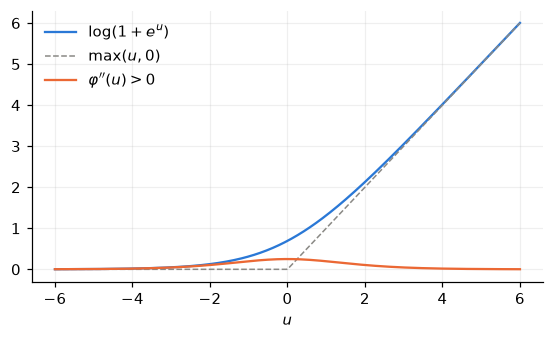

In [4]:
A = rng.normal(size=(20, 3)); b = rng.normal(size=20); y = np.sign(rng.normal(size=20))
lam = 0.5
f_lasso = lambda x: np.sum((A @ x - b) ** 2) + lam * np.abs(x).sum()
f_cheb  = lambda x: np.max(np.abs(A @ x - b))
f_logit = lambda x: np.sum(np.logaddexp(0, -y * (A @ x)))
sample = lambda: rng.uniform(-3, 3, 3)
for name, f in (("(а) LASSO", f_lasso), ("(б) Чебышёв", f_cheb), ("(в) логистическая", f_logit)):
    print(f"{name:18s} нарушение неравенства хорды на 5000 парах: {chord_violation(f, sample):.1e}")

u = np.linspace(-6, 6, 300); sig = 1 / (1 + np.exp(-u))
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(u, np.logaddexp(0, u), color=BLUE, label="$\\log(1 + e^u)$")
ax.plot(u, np.maximum(u, 0), color=GRAY, ls="--", lw=1, label="$\\max(u, 0)$")
ax.plot(u, sig * (1 - sig), color=ORANGE, label="$\\varphi''(u) > 0$")
ax.set(xlabel="$u$"); ax.legend(); plt.show()

Нарушений нет ни у одной из трёх — значения порядка $10^{-15}$ это ошибка округления, а не нарушение (что согласуется с доказательствами, но не заменяет их). Логистическая потеря — гладкий «мягкий» вариант функции $\max(u, 0)$, и её вторая производная строго положительна.

## 12.4. Проекция на параллелепипед

> Решите $\min_x \tfrac12\Vert x - p\Vert^2$ при $l \le x \le u$. Выведите из условия оптимальности $x^\ast_i = \min(\max(p_i, l_i), u_i)$ и проверьте численно.

**Шаг 1. Задача выпукла.** Цель строго выпукла ($\nabla^2 f = I$), множество — пересечение $2n$ полупространств. Значит, решение единственно, и условие оптимальности его характеризует.

**Шаг 2. Условие оптимальности.** $\nabla f(x) = x - p$, поэтому $x^\ast$ — решение тогда и только тогда, когда

$$\sum_{i=1}^n (x^\ast_i - p_i)(y_i - x^\ast_i) \ge 0 \quad \text{для всех } y \text{ с } l \le y \le u .$$

Параллелепипед — произведение отрезков, координаты $y_i$ можно менять независимо. Зафиксируем все $y_j = x^\ast_j$ при $j \ne i$; остаётся покоординатное условие

$$(x^\ast_i - p_i)(y_i - x^\ast_i) \ge 0 \quad \text{для всех } y_i \in [l_i, u_i].$$

**Шаг 3. Три случая для каждой координаты.**

- $l_i < x^\ast_i < u_i$: множитель $y_i - x^\ast_i$ принимает значения обоих знаков, значит, $x^\ast_i - p_i = 0$, то есть $x^\ast_i = p_i$ (и это возможно, только если $p_i \in (l_i, u_i)$).
- $x^\ast_i = l_i$: $y_i - l_i \ge 0$, поэтому нужно $l_i - p_i \ge 0$, то есть $p_i \le l_i$.
- $x^\ast_i = u_i$: $y_i - u_i \le 0$, поэтому нужно $u_i - p_i \le 0$, то есть $p_i \ge u_i$.

Итого $x^\ast_i = p_i$, если $p_i$ внутри отрезка, и ближайший конец отрезка иначе: $x^\ast_i = \min(\max(p_i, l_i), u_i)$. Это `np.clip(p, l, u)`. Ключевую роль сыграла *сепарабельность*: параллелепипед — произведение отрезков, а квадрат нормы — сумма по координатам. Для шара такой покоординатной формулы нет, там ответ $p/\Vert p\Vert$.

In [5]:
n = 5
l, u = -np.ones(n), np.ones(n)
p = rng.uniform(-2.5, 2.5, n)
res = minimize(lambda x: 0.5 * np.sum((x - p) ** 2), x0=np.zeros(n), jac=lambda x: x - p,
               method="L-BFGS-B", bounds=list(zip(l, u)))
print("p          =", p.round(3))
print("minimize   =", res.x.round(3))
print("np.clip    =", np.clip(p, l, u).round(3))
Y = rng.uniform(-1, 1, (5000, n))
print("min по случайным y величины (x* - p)^T (y - x*) = %.2e  (>= 0: условие выполнено)" % ((Y - res.x) @ (res.x - p)).min())

p          = [ 1.763 -2.083  2.003  2.035  1.678]
minimize   = [ 1. -1.  1.  1.  1.]
np.clip    = [ 1. -1.  1.  1.  1.]
min по случайным y величины (x* - p)^T (y - x*) = 4.04e-01  (>= 0: условие выполнено)


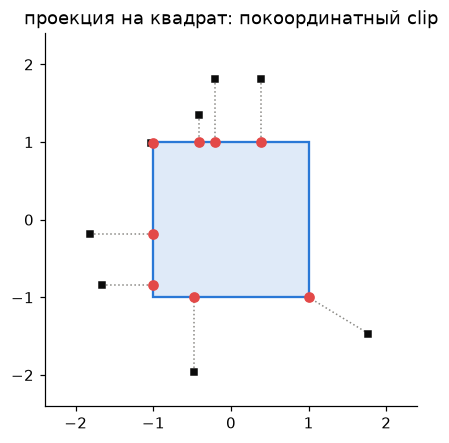

In [6]:
fig, ax = plt.subplots(figsize=(4.8, 4.4))
ax.add_patch(Rectangle((-1, -1), 2, 2, color=BLUE, alpha=0.15, lw=0)); ax.add_patch(Rectangle((-1, -1), 2, 2, fill=False, color=BLUE, lw=1.5))
for q in rng.uniform(-2.2, 2.2, (8, 2)):
    z = np.clip(q, -1, 1)
    ax.plot([q[0], z[0]], [q[1], z[1]], color=GRAY, ls=":", lw=1); ax.plot(*q, "s", color=INK, ms=4); ax.plot(*z, "o", color=RED, ms=6)
ax.set(aspect="equal", xlim=(-2.4, 2.4), ylim=(-2.4, 2.4), title="проекция на квадрат: покоординатный clip"); ax.grid(False)
plt.show()

## 12.5. Множество решений выпуклой задачи

> (а) Докажите, что множество решений выпуклой задачи выпукло, а при строго выпуклой $f$ решение единственно. (б) Приведите выпуклую задачу с бесконечным множеством решений. (в) Почему в примере 7.4 лекции 1 старт влияет на ответ, а в логистической регрессии — нет?

**(а)** Пусть $f^\ast$ — оптимальное значение. Множество решений $X^\ast = \{x \in \Omega : f(x) \le f^\ast\}$ — пересечение выпуклого $\Omega$ с подуровневым множеством выпуклой $f$, значит, выпукло. Если $f$ строго выпукла и $x^\ast \ne y^\ast$ — два решения, то середина $z = \tfrac12(x^\ast + y^\ast)$ допустима (выпуклость $\Omega$) и $f(z) < \tfrac12 f(x^\ast) + \tfrac12 f(y^\ast) = f^\ast$ — противоречие с оптимальностью $f^\ast$. Значит, решение одно.

**(б)** Любая LP, у которой линии уровня цели параллельны ребру многоугольника: пример 7.2 лекции 1 с прибылью $7.5x_1 + 5x_2$ — оптимально всё ребро между $(2, 6)$ и $(4, 3)$. Или безусловная $f(x) = (x_1 + x_2 - 1)^2$: решения — вся прямая $x_1 + x_2 = 1$. В обоих случаях $f$ выпукла, но не строго. Множество решений при этом выпукло (отрезок, прямая) — в согласии с (а).

**(в)** $f(x) = (x^2 - 1)^2 + 0.3x$ не выпукла: у неё две «ямы», разделённые горбом, и метод спуска остаётся в той яме, где стартовал. Логистическая потеря выпукла (упр. 12.3в), и по главной теореме лекции любой её локальный минимум глобален; при $\lambda > 0$ она ещё и строго выпукла, так что минимум единственный. Метод из любого старта сходится к одной и той же точке — старт влияет лишь на число итераций.

In [7]:
A_ub = np.array([[1.0, 0.0], [0.0, 2.0], [3.0, 2.0]]); b_ub = np.array([4.0, 12.0, 18.0])
c = np.array([7.5, 5.0])
res = linprog(-c, A_ub=A_ub, b_ub=b_ub, bounds=[(0, None)] * 2, method="highs")
print("linprog вернул вершину x* =", res.x, " прибыль =", -res.fun)
for pt in ([2, 6], [3, 4.5], [4, 3]):
    print(f"   точка {pt}: прибыль = {c @ pt}  (то же значение — всё ребро оптимально)")

linprog вернул вершину x* = [2. 6.]  прибыль = 45.0
   точка [2, 6]: прибыль = 45.0  (то же значение — всё ребро оптимально)
   точка [3, 4.5]: прибыль = 45.0  (то же значение — всё ребро оптимально)
   точка [4, 3]: прибыль = 45.0  (то же значение — всё ребро оптимально)


## Вопросы для самопроверки

Ответы на вопросы из конца конспекта.

**1. Определения и связь.** Множество выпукло, если вместе с любыми двумя точками содержит отрезок между ними: $(1-t)x + ty \in \Omega$ при $t \in [0, 1]$. Функция выпукла на выпуклом множестве, если хорда лежит не ниже графика: $f((1-t)x + ty) \le (1-t)f(x) + tf(y)$. Связь: $f$ выпукла тогда и только тогда, когда её надграфик $\{(x, s) : s \ge f(x)\}$ — выпуклое множество. Поэтому всё, что известно про множества (пересечения, аффинные образы), переносится на функции: максимум выпуклых функций выпукл, потому что его надграфик — пересечение надграфиков.

**2. Критерии.** Первого порядка: $f \in C^1$ выпукла $\iff f(y) \ge f(x) + \nabla f(x)^\top(y - x)$ для всех $x, y$ (график над касательной). Второго порядка: $f \in C^2$ выпукла $\iff \nabla^2 f(x) \succeq 0$ всюду. Для квадратичной $\tfrac12 x^\top Qx + c^\top x$ гессиан постоянен и равен $Q$, поэтому она выпукла $\iff Q \succeq 0$ (все собственные числа неотрицательны), строго выпукла $\iff Q \succ 0$.

**3. Выпуклая стандартная форма.** $f$ выпукла, все равенства $g_i$ аффинны, все $h_i$ в неравенствах $h_i(x) \ge 0$ вогнуты. Равенство $g_i(x) = 0$ — это два неравенства $g_i \ge 0$ и $-g_i \ge 0$; чтобы оба задавали выпуклые множества, $g_i$ должна быть одновременно вогнутой и выпуклой, то есть аффинной. Нелинейное равенство задаёт «кривую поверхность», и отрезок между её точками с неё сходит (окружность).

**4. Условие оптимальности.** Для выпуклой задачи $x^\ast \in \Omega$ — глобальное решение $\iff \nabla f(x^\ast)^\top (y - x^\ast) \ge 0$ для всех $y \in \Omega$. Геометрически: ни в одном допустимом направлении $f$ не убывает в первом порядке; антиградиент образует неострый угол со всеми направлениями внутрь $\Omega$, «смотрит наружу». Без ограничений направления есть во все стороны, и условие превращается в $\nabla f(x^\ast) = 0$ — для выпуклых функций оно необходимо и достаточно.

## Что запомнить

- Опровергнуть выпуклость — одна пара точек (отрезок вышел, хорда под графиком, отрицательное собственное число гессиана в одной точке). Доказать — критерий, операции или определение для *всех* пар (12.1, 12.2).
- Множество вида $\{x : x_1 x_2 \ge 1, x > 0\}$ выпукло, хотя функция $x_1 x_2$ нет: смотреть нужно на множество, а не на формулу (12.1в).
- Сумма квадратов плюс норма, максимум модулей, логистическая потеря — выпуклы по операциям; гладкая из них только последняя (12.3).
- Проекция на параллелепипед — `clip`; вывод — из условия оптимальности по каждой координате отдельно, спасибо сепарабельности (12.4).
- Множество решений выпуклой задачи выпукло, при строгой выпуклости — точка; старт метода не влияет на ответ (12.5).